<a href="https://colab.research.google.com/github/apester/IME/blob/main/graph_analytics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph-Theoretical Methods for Data Analytics — Hands-on Lab

This notebook accompanies the lecture deck **“Graph-Theoretical Methods for Data Analytics”**.

You'll build graphs from data, compute metrics, detect communities with **Louvain**, quantify **modularity**, and turn results into analytics outputs (segments, anomalies, features).

---

## What you'll do
1. **Graph refresher** (toy graphs + adjacency matrices)
2. **Metrics** (degree, clustering, betweenness, PageRank)
3. **Communities + modularity** (Louvain)
4. **Similarity graphs** (kNN from vectors)
5. **Correlation network modeling** (thresholded correlation graph)
6. **Link prediction** (simple baselines)
7. **Dynamic graphs** (metrics over time)


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

# NetworkX community tools (available in NetworkX 3.x)
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 5)


## 1) Graph theory refresher: a graph and its adjacency matrix

A graph is \(G=(V,E)\). The adjacency matrix \(A\) stores edge weights:
- \(A\_ij=1\) if there's an edge, else 0 (unweighted)
- \(A_ij=w_ij\) if weighted


Adjacency matrix A:
 [[0 1 0 1]
 [1 0 1 1]
 [0 1 0 1]
 [1 1 1 0]]


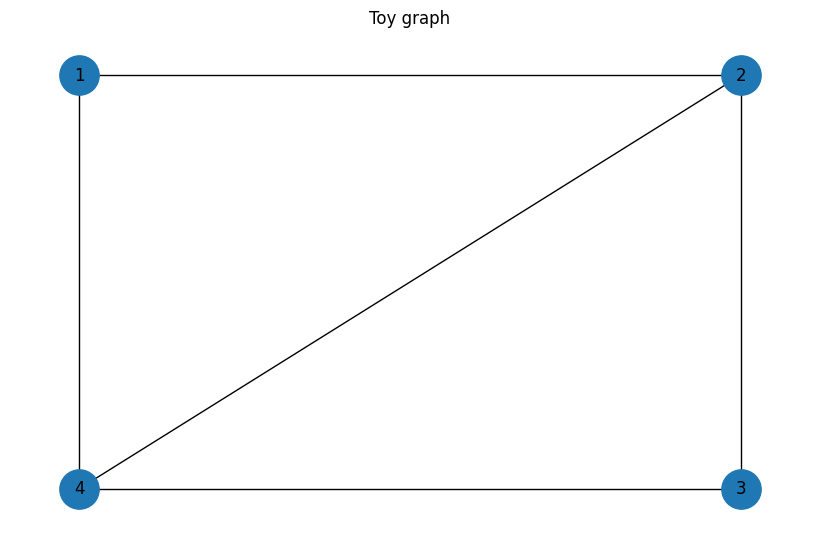

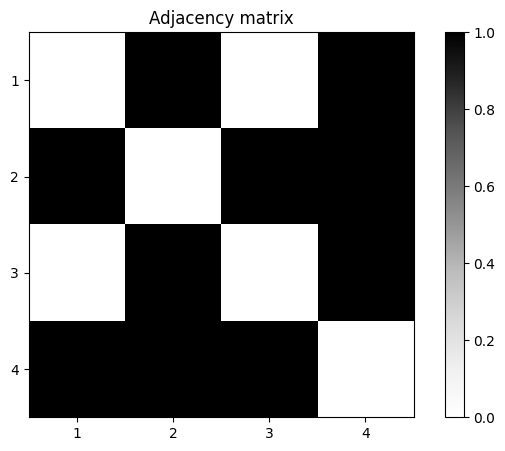

In [2]:
# Create a small toy graph
G = nx.Graph()
G.add_edges_from([(1,2),(2,3),(3,4),(4,1),(2,4)])

A = nx.to_numpy_array(G, nodelist=[1,2,3,4])
print("Adjacency matrix A:\n", A.astype(int))

# Visualize
pos = {1:(0,1), 2:(1,1), 3:(1,0), 4:(0,0)}
nx.draw(G, pos, with_labels=True, node_size=800)
plt.title("Toy graph")
plt.show()

plt.imshow(A, cmap="Greys", vmin=0, vmax=1)
plt.xticks(range(4), [1,2,3,4])
plt.yticks(range(4), [1,2,3,4])
plt.title("Adjacency matrix")
plt.colorbar()
plt.show()


## 2) Metrics: degree, clustering, betweenness, PageRank

These turn graph structure into **numbers you can analyze** (and feed into ML).


In [3]:
# Metrics on the toy graph
deg = dict(G.degree())
clust = nx.clustering(G)
bet = nx.betweenness_centrality(G)
pr = nx.pagerank(G)

df = pd.DataFrame({
    "degree": pd.Series(deg),
    "clustering": pd.Series(clust),
    "betweenness": pd.Series(bet),
    "pagerank": pd.Series(pr),
}).sort_index()

df


,degree,clustering,betweenness,pagerank
1,2,1.000000,0.000000,0.204787
2,3,0.666667,0.166667,0.295213
3,2,1.000000,0.000000,0.204787
4,3,0.666667,0.166667,0.295213


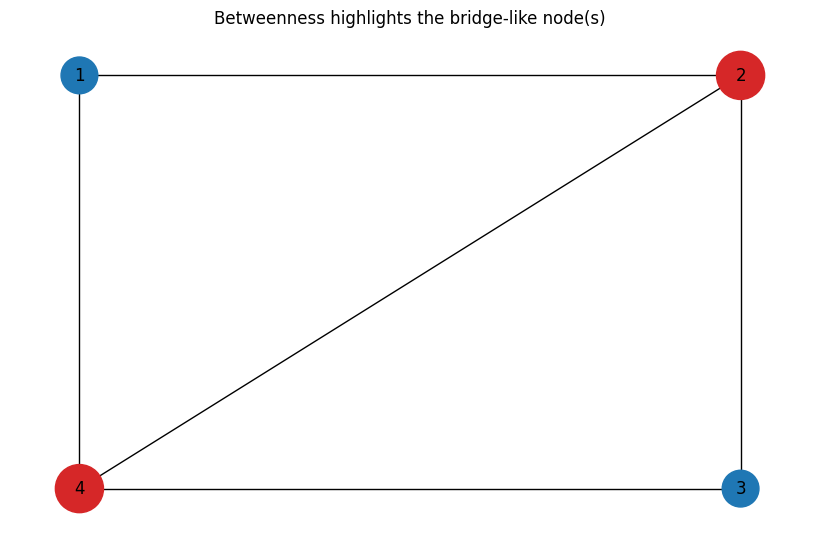

In [4]:
# Quick visualization: which node is a "bridge"?
node_sizes = [1200 if bet[n] == max(bet.values()) else 700 for n in G.nodes()]
node_colors = ["tab:red" if bet[n] == max(bet.values()) else "tab:blue" for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color=node_colors)
plt.title("Betweenness highlights the bridge-like node(s)")
plt.show()


## 3) Communities + modularity (Louvain)

**Louvain** finds a partition that (heuristically) maximizes **modularity**.

Modularity (one common form):

\[
Q=\frac{1}{2m}\sum_{i,j}\left(A_{ij}-\frac{k_i k_j}{2m}\right)\delta(c_i,c_j)
\]

High \(Q\) means **more within-community connections than expected by chance**.


In [5]:
# Classic demo graph
K = nx.karate_club_graph()

# Louvain communities (NetworkX)
comms = louvain_communities(K, seed=0)
Q = modularity(K, comms)

print(f"Found {len(comms)} communities; modularity Q = {Q:.3f}")
[sorted(list(c))[:10] for c in comms]  # peek


Found 4 communities; modularity Q = 0.444


[[0, 1, 2, 3, 7, 11, 12, 13, 17, 19],
 [4, 5, 6, 10, 16],
 [8, 9, 14, 15, 18, 20, 22, 23, 26, 27],
 [24, 25, 28, 31]]

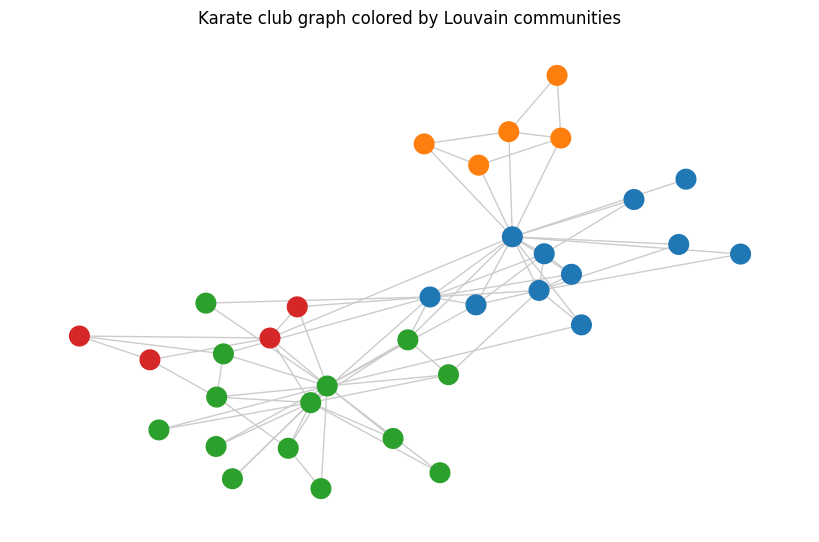

In [6]:
# Visualize communities
pos = nx.spring_layout(K, seed=3)
palette = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"]

node2c = {}
for i,c in enumerate(comms):
    for n in c:
        node2c[n] = i

colors = [palette[node2c[n] % len(palette)] for n in K.nodes()]

nx.draw(K, pos, node_color=colors, with_labels=False, node_size=200, edge_color="#cccccc")
plt.title("Karate club graph colored by Louvain communities")
plt.show()


## 4) Similarity graphs from vectors (kNN graph)

When you have tabular vectors (customers, documents, sensor summaries), you can:
- compute distances/similarities
- connect each point to its **k nearest neighbors**
- run community detection for **unsupervised segmentation**


In [7]:
# Synthetic clusters (like customers in feature space)
X, y = make_blobs(n_samples=200, centers=3, cluster_std=1.2, random_state=2)

k = 8
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
dist, idx = nbrs.kneighbors(X)

# Build undirected kNN graph
Gk = nx.Graph()
Gk.add_nodes_from(range(len(X)))
for i in range(len(X)):
    for j in idx[i, 1:]:
        Gk.add_edge(i, j, weight=float(np.linalg.norm(X[i]-X[j])))

print(Gk.number_of_nodes(), "nodes,", Gk.number_of_edges(), "edges")


200 nodes, 1022 edges


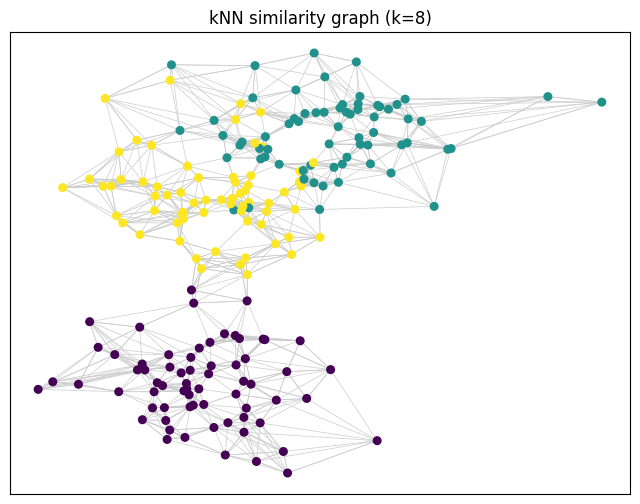

In [8]:
# Plot embedded points with kNN edges
plt.figure(figsize=(8,6))
for i in range(len(X)):
    for j in idx[i, 1:]:
        plt.plot([X[i,0], X[j,0]],[X[i,1], X[j,1]], color="#cccccc", lw=0.5, zorder=1)
plt.scatter(X[:,0], X[:,1], c=y, s=30, zorder=2)
plt.title(f"kNN similarity graph (k={k})")
plt.xticks([]); plt.yticks([])
plt.show()


In [9]:
# Louvain on similarity graph
comms_k = louvain_communities(Gk, seed=0)
Qk = modularity(Gk, comms_k, weight=None)  # weights here represent distance; treat unweighted for modularity demo

print(f"kNN graph communities: {len(comms_k)}; modularity Q = {Qk:.3f}")

# Compare with true blob labels: purity-like quick check (not a formal metric)
node2c = {}
for i,c in enumerate(comms_k):
    for n in c:
        node2c[n] = i

df_seg = pd.DataFrame({"true": y, "community": pd.Series(node2c)})
df_seg.groupby("community")["true"].value_counts(normalize=True).head(15)


kNN graph communities: 7; modularity Q = 0.727


community  true
0          2       0.592593
           0       0.259259
           1       0.148148
1          1       0.433333
           0       0.333333
           2       0.233333
2          0       0.361111
           1       0.333333
           2       0.305556
3          0       0.500000
           1       0.300000
           2       0.200000
4          1       0.400000
           0       0.300000
           2       0.300000
Name: proportion, dtype: float64

## 5) Correlation network modeling (thresholded correlation graph)

Pattern:
1. get a feature vector per subject
2. correlation matrix across subjects
3. threshold correlations → adjacency
4. Louvain → groups
5. profile groups (means, variances, etc.)


In [10]:
# Synthetic 'participants' with 3 latent behavior modes
n = 30
group_sizes = [10, 10, 10]
T = 200

latent = np.random.randn(3, T)
Xsub = []
labels = []
for g, sz in enumerate(group_sizes):
    for _ in range(sz):
        Xsub.append(latent[g] + 0.4*np.random.randn(T))
        labels.append(g)
Xsub = np.array(Xsub)
labels = np.array(labels)

corr = np.corrcoef(Xsub)
thr = 0.6
A = (corr > thr).astype(int)
np.fill_diagonal(A, 0)

Gc = nx.from_numpy_array(A)
print("Correlation graph:", Gc.number_of_nodes(), "nodes,", Gc.number_of_edges(), "edges")


Correlation graph: 30 nodes, 135 edges


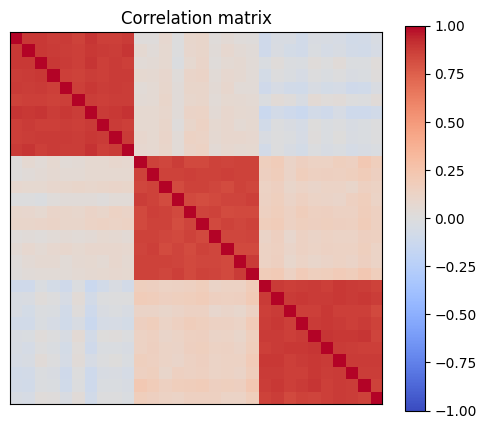

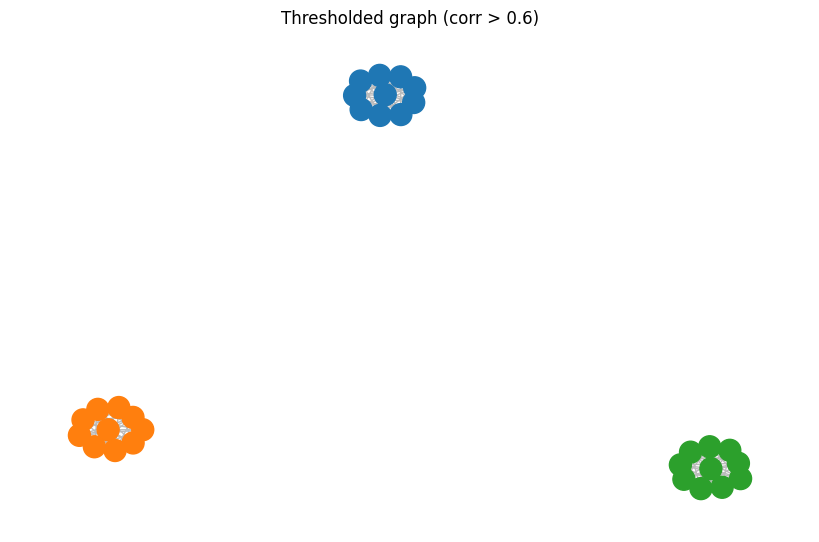

In [11]:
# Visualize: correlation matrix + thresholded graph
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.colorbar()
plt.xticks([]); plt.yticks([])
plt.show()

pos = nx.spring_layout(Gc, seed=5)
palette = ["tab:blue","tab:orange","tab:green"]
node_colors = [palette[labels[i]] for i in range(n)]
nx.draw(Gc, pos, node_color=node_colors, node_size=250, edge_color="#bbbbbb")
plt.title(f"Thresholded graph (corr > {thr})")
plt.show()


In [12]:
# Louvain communities + modularity
comms_c = louvain_communities(Gc, seed=0)
Qc = modularity(Gc, comms_c)

print(f"Found {len(comms_c)} communities; modularity Q = {Qc:.3f}")

# Community profiles: here we'll summarize the original time-series by simple features
features = pd.DataFrame({
    "mean": Xsub.mean(axis=1),
    "std": Xsub.std(axis=1),
    "skew": ((Xsub - Xsub.mean(axis=1, keepdims=True))**3).mean(axis=1) / (Xsub.std(axis=1)**3 + 1e-9),
})

node2c = {}
for i,c in enumerate(comms_c):
    for n in c: node2c[n] = i

features["community"] = pd.Series(node2c)
features.groupby("community").mean()


Found 3 communities; modularity Q = 0.667


,mean,std,skew
community,,,
0,0.066632,1.087888,0.099505
1,-0.137884,1.009078,-0.007063
2,-0.106207,1.122260,-0.228606


## 6) Link prediction (simple baseline)

We'll hide a fraction of edges, score candidate pairs using **common neighbors**, and evaluate with AUC.
(Real systems often use embeddings or supervised models, but baselines teach the idea.)


In [13]:
# Build a graph and create a train/test split for edges
G0 = nx.karate_club_graph()
edges = list(G0.edges())
np.random.shuffle(edges)

test_frac = 0.15
m_test = int(len(edges)*test_frac)
test_edges = edges[:m_test]
train_edges = edges[m_test:]

Gtrain = nx.Graph()
Gtrain.add_nodes_from(G0.nodes())
Gtrain.add_edges_from(train_edges)

# Candidate pairs: positives = held-out edges; negatives = random non-edges
pos_pairs = test_edges
non_edges = list(nx.non_edges(G0))
neg_pairs = [non_edges[i] for i in np.random.choice(len(non_edges), size=len(pos_pairs), replace=False)]

def common_neighbors_score(G, u, v):
    return len(list(nx.common_neighbors(G, u, v)))

y_true = np.array([1]*len(pos_pairs) + [0]*len(neg_pairs))
scores = np.array([common_neighbors_score(Gtrain, *p) for p in pos_pairs] +
                  [common_neighbors_score(Gtrain, *p) for p in neg_pairs])

auc = roc_auc_score(y_true, scores)
print(f"AUC (common neighbors baseline) = {auc:.3f}")


AUC (common neighbors baseline) = 0.847


## 7) Dynamic graphs: metrics over time

When edges change over time, you can compute metrics per snapshot and monitor drift.


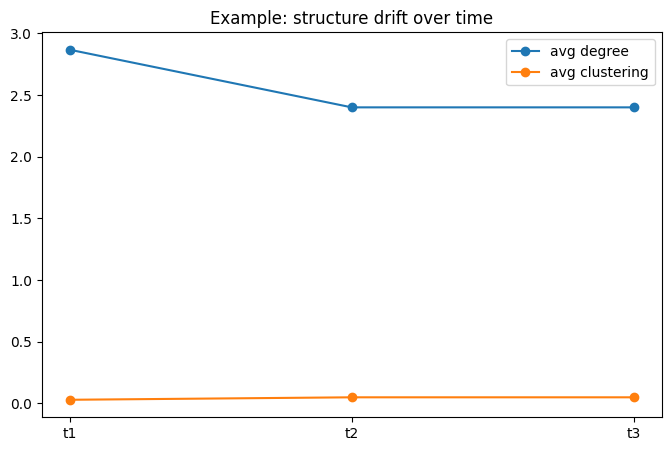

In [14]:
def snapshot(seed, extra=False):
    G = nx.erdos_renyi_graph(30, 0.08, seed=seed)
    if extra:
        # inject a 'bridge' edge to change structure
        G.add_edge(0, 15)
        G.add_edge(0, 16)
    return G

Gs = [snapshot(1), snapshot(2, extra=True), snapshot(3, extra=True)]
deg0 = [np.mean([d for _,d in G.degree()]) for G in Gs]
cc0 = [nx.average_clustering(G) for G in Gs]

plt.plot([1,2,3], deg0, marker="o", label="avg degree")
plt.plot([1,2,3], cc0, marker="o", label="avg clustering")
plt.xticks([1,2,3], ["t1","t2","t3"])
plt.title("Example: structure drift over time")
plt.legend()
plt.show()


### References (optional reading)

- Blondel et al. (2008) **Louvain / fast unfolding**: https://arxiv.org/abs/0803.0476  
- Newman & Girvan (2004) **modularity / community structure** (see citation chain): https://igraph.org/c/html/0.9.5/igraph-Community.html  
- NetworkX docs: **modularity** and **Louvain**  
  - https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html  
  - https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html  
- DeepWalk (2014): https://arxiv.org/abs/1403.6652  
- node2vec (2016): https://arxiv.org/abs/1607.00653  


## Wrap-up

You now have a repeatable pattern:

**Data → graph → metrics/communities → analytics output**

Try this next:
- swap the synthetic data for your real dataset
- experiment with **k**, thresholds, and the **resolution** parameter in Louvain
- validate by downstream lift (AUC/F1) or by interpretability of segments
